In [14]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
print(f"numpy version: {np.__version__}")
print(f"scipy version: {sp.__version__}")
print(f"matplotlib version: {plt.matplotlib.__version__}")

numpy version: 2.4.0
scipy version: 1.17.1
matplotlib version: 3.10.8


In [15]:
# estimating population parameters using random samples

n = 1000
y = np.random.normal(loc=100, scale=15, size=n)
print(f"sample = {y[0:10].round(2)}")
print(f"sample mean = {y.mean():.2f}")
print(f"sample sd =  {y.std():.2f}")

# standard error of the mean (SEM)
# SEM is the standard deviation of the theoretical distribution of the sample means
# (otherwise known as the "sampling distribution of means")

sem = y.std() / math.sqrt(n)
print(f"standard error of the mean = {sem:.2f}")

sample = [126.41  98.34  58.5  103.81  87.19 103.07  76.73 105.13  98.47 109.29]
sample mean = 99.97
sample sd =  14.71
standard error of the mean = 0.47


100%|██████████| 10000/10000 [00:00<00:00, 53836.70 simulation /s]


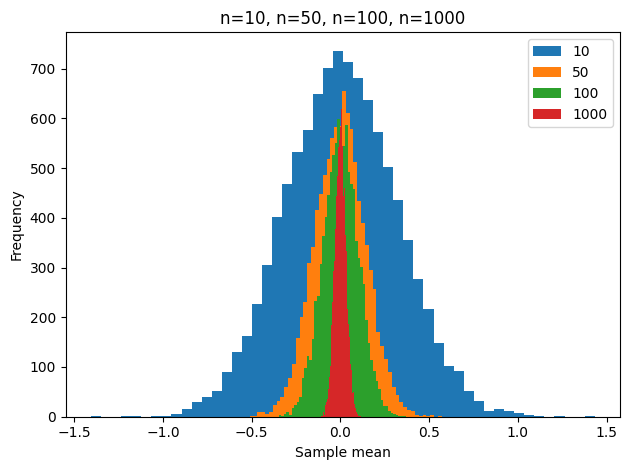

In [16]:
# illustration of the role of sample size

#samp_sizes = [10]
samp_sizes = [10, 50, 100, 1000]
nsims = 10000
for n in samp_sizes:
    ymeans = np.zeros(nsims)
    for i in tqdm(range(nsims), unit = " simulation "):
        y = np.random.normal(0, 1, n)
        ymeans[i] = np.mean(y)
    plt.hist(ymeans, bins=50)
plt.xlim = (-1.1, 1.1)
plt.legend(samp_sizes)
plt.title("n=10, n=50, n=100, n=1000")
plt.xlabel("Sample mean")
plt.ylabel("Frequency")
plt.tight_layout()

Correlation between x and y: 0.5242771404568689


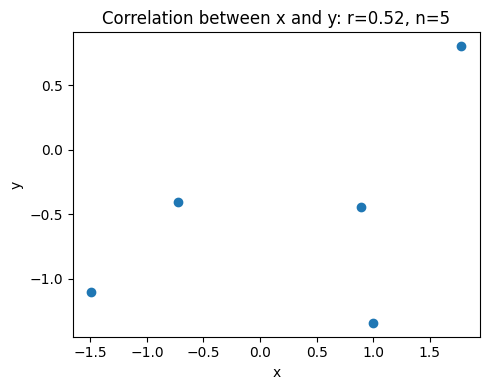

In [17]:
# correlations under the null hypothesis

n = 5
x = np.random.normal(0, 1, n)
y = np.random.normal(0, 1, n)
r = sp.stats.pearsonr(x, y)[0]
print(f"Correlation between x and y: {r}")
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Correlation between x and y: r={r.round(2)}, n={n}")
plt.tight_layout()

100%|██████████| 10000/10000 [00:01<00:00, 6692.67 simulations /s]


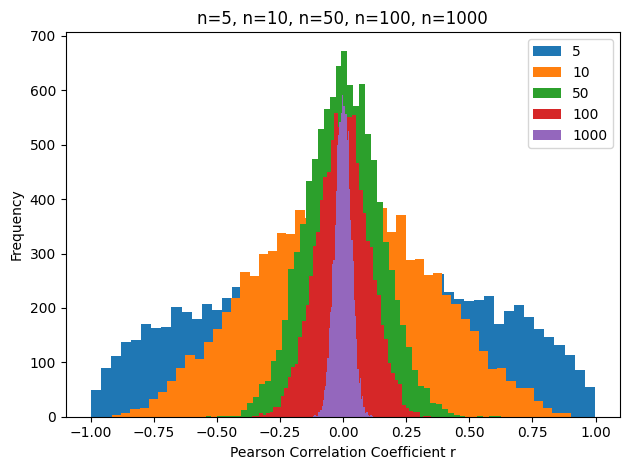

In [18]:
# correlations & sample size

#samp_sizes = [5]
samp_sizes = [5, 10, 50, 100, 1000]
nsims = 10000
for n in samp_sizes:
    rvalues = np.zeros(nsims)
    for i in tqdm(range(nsims), unit=" simulations "):
        y1 = np.random.normal(0, 1, n)
        y2 = np.random.normal(0, 1, n)
        rvalues[i] = sp.stats.pearsonr(y1, y2)[0]
    plt.hist(rvalues, bins=50)
plt.xlim = (-1.1, 1.1)
plt.legend(samp_sizes)
plt.title("n=5, n=10, n=50, n=100, n=1000")
plt.xlabel("Pearson Correlation Coefficient r")
plt.ylabel("Frequency")
plt.tight_layout()

In [19]:
# null hypothesis significance testing
# H0 true

pop_mean   = 100
pop_sd     = 15
pop_effect =  0   # <--- the actual effect of the drug
n          = 10
placebo = (np.random.randn(n) * pop_sd) + pop_mean
drug    = (np.random.randn(n) * pop_sd) + pop_mean + pop_effect
placebo, drug = placebo.round(decimals=0), drug.round(decimals=0)
print(f"placebo : {placebo}")
print(f"drug    : {drug}")
print(f"placebo mean : {placebo.mean()}")
print(f"drug mean    : {drug.mean()}")
results = sp.stats.ttest_ind(drug, placebo) # independent samples t-test
print(f"t({results.df}) = {results.statistic.round(2)}, p = {results.pvalue.round(5)}")

placebo : [129. 114.  69. 101. 113.  94. 104. 111.  70. 112.]
drug    : [112. 117.  96.  66.  93.  99. 111.  84.  90. 126.]
placebo mean : 101.7
drug mean    : 99.4
t(18.0) = -0.28, p = 0.78418


In [20]:
# null hypothesis significance testing
# H0 false

pop_mean   = 100
pop_sd     = 15
pop_effect =  8   # <--- the actual effect of the drug
n          = 10
placebo = (np.random.randn(n) * pop_sd) + pop_mean
drug    = (np.random.randn(n) * pop_sd) + pop_mean + pop_effect
placebo, drug = placebo.round(decimals=0), drug.round(decimals=0)
print(f"placebo : {placebo}")
print(f"drug    : {drug}")
print(f"placebo mean : {placebo.mean()}")
print(f"drug mean    : {drug.mean()}")
results = sp.stats.ttest_ind(drug, placebo) # independent samples t-test
print(f"t({results.df}) = {results.statistic.round(2)}, p = {results.pvalue.round(5)}")

placebo : [101. 114.  92.  97.  68.  87. 110. 118. 109.  94.]
drug    : [116.  98.  98.  99. 112. 104. 116. 108. 106. 127.]
placebo mean : 99.0
drug mean    : 108.4
t(18.0) = 1.69, p = 0.1091


In [21]:
# function to simulate one experiment
def simulate_experiment(n=10, pop_effect=0, alpha=0.05, pop_mean=100, pop_sd=15, verbose=False):
    placebo = (np.random.randn(n) * pop_sd) + pop_mean
    drug    = (np.random.randn(n) * pop_sd) + pop_mean + pop_effect
    placebo, drug = placebo.round(decimals=0), drug.round(decimals=0)
    results = sp.stats.ttest_ind(drug, placebo) # independent samples t-test
    if (results.pvalue < alpha):
        results.decision = "H1"
    else:
        results.decision = "H0"
    if (verbose==True):
        print(f"placebo : {placebo}")
        print(f"drug    : {drug}")
        print(f"placebo mean : {placebo.mean()}")
        print(f"drug mean    : {drug.mean()}")
        print(f"t({results.df}) = {results.statistic.round(2)}, p = {results.pvalue.round(5)}")
    return results

In [22]:
results = simulate_experiment(pop_effect = 8, verbose=True)

placebo : [115.  99. 102.  82.  76.  86.  95. 146. 120.  85.]
drug    : [109. 133.  92. 106. 125. 104. 120. 115.  78. 130.]
placebo mean : 100.6
drug mean    : 111.2
t(18.0) = 1.22, p = 0.23687


100%|██████████| 10000/10000 [00:02<00:00, 3440.31 experiments /s]


you made a type I error 5.4 % of the time 


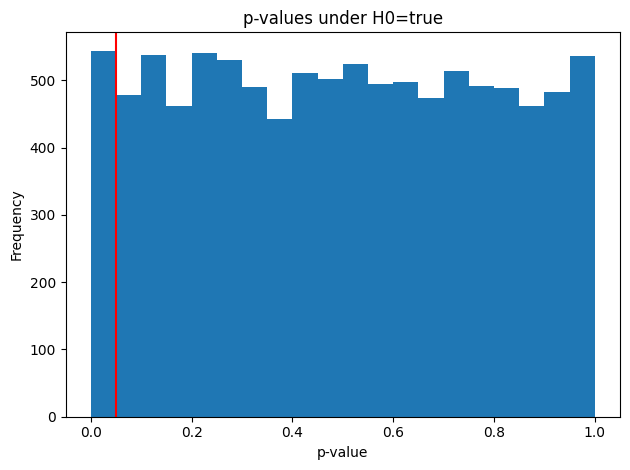

In [23]:
# simulate many experiments under the null hypothesis

mean_diff =  0
n         = 10
pop_sd    = 15
alpha     = 0.05

n_simulations = 10000
p_values = np.zeros(n_simulations)
decision = np.zeros(n_simulations) # 0=H0, 1=H1
for i in tqdm(range(n_simulations), unit=" experiments "):
    results = simulate_experiment(n=n, alpha=alpha, pop_sd=pop_sd, pop_effect=mean_diff, verbose=False)
    p_values[i] = results.pvalue
    decision[i] = results.decision=="H1"
plt.hist(p_values, bins=20)
plt.xlim = (0,1)
plt.title("p-values under H0=true")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.axvline(alpha, color="red")
plt.tight_layout()

type_I_errors = sum(decision)/n_simulations
print(f"you made a type I error {type_I_errors*100:.1f} % of the time ")

100%|██████████| 10000/10000 [00:02<00:00, 3494.46 experiments /s]

you made a type II error 79.5 % of the time 
your statistical power was 0.2


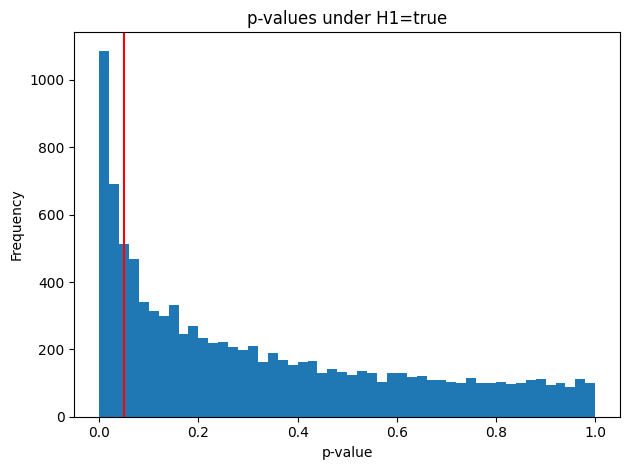

In [24]:
# simulate many experiments under the alternate hypothesis

mean_diff =  8
n         = 10
pop_sd    = 15
alpha     = 0.05

n_simulations = 10000
p_values = np.zeros(n_simulations)
decision = np.zeros(n_simulations) # 0=H0, 1=H1
for i in tqdm(range(n_simulations), unit=" experiments "):
    results = simulate_experiment(n=n, alpha=alpha, pop_sd=pop_sd, pop_effect=mean_diff, verbose=False)
    p_values[i] = results.pvalue
    decision[i] = results.decision=="H1"
plt.hist(p_values, bins=50)
plt.xlim = (0,1)
plt.title("p-values under H1=true")
plt.xlabel("p-value")
plt.ylabel("Frequency")
plt.axvline(alpha, color="red")
plt.tight_layout()

type_II_errors = sum(decision==0)/n_simulations
print(f"you made a type II error {type_II_errors*100:.1f} % of the time ")
print(f"your statistical power was {1-type_II_errors:.1f}")